# Food.com Recipe Makeup Analysis and Recipe Prediction
by Adrianne Steven See and Aarman Sachdev

## Overview

This Data Science project explores the effectiveness of predictive models in understanding a 'Five Star Rating' for any given user recipe from Food.com.

## Introduction

Food.com is one of the largest food preparation websites on the Internet, hosting over 500,000 user made recipes from around the world, as well as feedback, reviews and images of other users making them at home. Launching in 2017 to great success, its recipes have since garnered an active community of home cooks looking to enjoy a good recipe. Food.com is not home to just home users, though, as many celebrities, chefs, and popular companies have both derived and official recipes published as well. 

Because of this, understanding what drives a 'Five Star Rating' becomes highly important. From promotional avenues, to publicity stunts, to establishing a mini community, individuals and businessses can serve to profit from releasing well received recipes on this website. Numerical insights can also help home cooks and food platforms recommend meals that people will actually enjoy. Depending on factors such as nutrition content, calorie density, and simplicity of preparation, general trends in food preferences can also be discovered. Finally, trends towards ingredients or tags can help any recipe maker promote or create recipes that are timely and well received by users.

Our main motivation from understanding the dataset is **which recipe characteristics, contained within the dataset, are correlated with Five-Star Food.com recipes?**

To perform this analysis, this project analyzes a subset of  user recipes and  user ratings from Food.com. Each recipe includes nutritional information, preparation details, and user-submitted ratings. 

The first dataset we want to leverage, `recipe`, contains a subset (83,782) of all user submitted recipes uploaded to Food.com. Each entry represents a unique recipe submitted and viewable on the website, and contains the following features:

| Column Name | Description | 
|--------|-------------------|
| `name` | Recipe name |
| `id` | Recipe ID |
| `minutes` | Minutes to prepare recipe2 |
| `contributor_id`	 | User ID who submitted this recipe |
| `submitted` | Date recipe was submitted |
| `tags` | Food.com tags for recipe |
| `nutrition` | Nutrition information in the form [calories (#), total fat (PDV), sugar (PDV), sodium (PDV), protein (PDV), saturated fat (PDV), carbohydrates (PDV)]; PDV stands for - “percentage of daily value” |
| `n_steps` | Number of steps in recipe |
| `steps` | Text for recipe steps, in order |
| `description` | User-provided description |

The second dataset we want to leverage, `ratings`, contains a subset (731,927) of all user submitted ratings uploaded to Food.com. Each entry represents a unique review for a unique recipe on the website, and contains the following features:

| Column Name | Description | 
|--------|-------------------|
| `user_id'` | User ID |
| `recipe_id` | Recipe ID |
| `date` | Date of interaction |
| `rating`	 | Rating given |
| `review` | Review text |

**Relevant Columns:**
- `calories`: extracted from the `nutrition` column, represents total calories per serving
- `avg_rating`: average user rating for each recipe (1-5 scale)
- `n_steps`: number of steps in the recipe
- `n_ingredients`: number of ingredients
- `minutes`: total preparation time
- `tags`: user assigned tags to describe recipe
- `ingredients`: Ingredients

In [1]:
# Setup Cell, run once

# Import relevant modules
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Adjust graphing module settings
plt.rcParams['figure.figsize'] = (12, 6)
sns.set(font_scale=1.2, style="white")
pd.options.plotting.backend = 'plotly'

#Load data
recipes = pd.read_csv('Data/RAW_recipes.csv')
interactions = pd.read_csv('Data/interactions.csv')

In [2]:
# Print recipes dataset descriptions
print(f'Food.com recipes dataset sample contains {recipes.shape[0]} entries with {recipes.shape[1]} features\n')
print(f"Datatypes of recipes Dataset\n{recipes.dtypes}\n")
print(f"Null entries of recipes Dataset\n{recipes.isna().sum()}\n")
recipes.head()

Food.com recipes dataset sample contains 83782 entries with 12 features

Datatypes of recipes Dataset
name              object
id                 int64
minutes            int64
contributor_id     int64
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object

Null entries of recipes Dataset
name               1
id                 0
minutes            0
contributor_id     0
submitted          0
tags               0
nutrition          0
n_steps            0
steps              0
description       70
ingredients        0
n_ingredients      0
dtype: int64



,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,1 brownies in the world best ever,333281,40,985201,2008-10-27,"['60-minutes-or-less', 'time-to-make', 'course...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...","['bittersweet chocolate', 'unsalted butter', '...",9
1,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"['60-minutes-or-less', 'time-to-make', 'cuisin...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,"['white sugar', 'brown sugar', 'salt', 'margar...",11
2,412 broccoli casserole,306168,40,50969,2008-05-30,"['60-minutes-or-less', 'time-to-make', 'course...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,"['frozen broccoli cuts', 'cream of chicken sou...",9
3,millionaire pound cake,286009,120,461724,2008-02-12,"['time-to-make', 'course', 'cuisine', 'prepara...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,"['butter', 'sugar', 'eggs', 'all-purpose flour...",7
4,2000 meatloaf,475785,90,2202916,2012-03-06,"['time-to-make', 'course', 'main-ingredient', ...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...","['meatloaf mixture', 'unsmoked bacon', 'goat c...",13


In [3]:
# Print interactions dataset descriptions
print(f'Food.com interactions dataset sample contains {interactions.shape[0]} entries with {interactions.shape[1]} features\n')
print(f"Datatypes of interactions Dataset\n{interactions.dtypes}\n")
print(f"Null entries of interactions Dataset\n{interactions.isna().sum()}\n")
interactions.head()

Food.com interactions dataset sample contains 731927 entries with 5 features

Datatypes of interactions Dataset
user_id       int64
recipe_id     int64
date         object
rating        int64
review       object
dtype: object

Null entries of interactions Dataset
user_id        0
recipe_id      0
date           0
rating         0
review       169
dtype: int64



,user_id,recipe_id,date,rating,review
0,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
1,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
2,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."
3,124416,120345,2011-08-06,0,"Just an observation, so I will not rate. I fo..."
4,2000192946,120345,2015-05-10,2,This recipe was OVERLY too sweet. I would sta...


## Step 2: Data Cleaning and Exploratory Data Analysis

### Data Cleaning

While useful, the dataset is split into multiple parts. To simplify analysis and prediction, we will combine the information into one usable and analyzable dataset. To do so, teh following transformations were done.

1. **Merged recipes and interactions:** We performed a left merge on the `recipes` dataset with the `interactions` dataset, on `id` for recipes and `recipe_id` with interactions. This was done to associate each recipe with a rating column.

2. **Replaced 0 ratings with NaN:** Ratings of 0 were replaced with `np.nan`. After testing, a user account was unable to give a rating of 0 stars. This supports the conclusion that recipe ratings of zero stars are more likely due to data error or lack of user rating, rather than genuine ratings. Replacing 0's with `np.nan` prevents them from skewing the rating values when computing the mean rating per recipe.

3. **Computed average rating per recipe:** The mean rating for each recipe was calculated and assigned onto the `recipes` dataset as `avg_rating`.

4. **Parsed nutrition column:** The `nutrition` column stores `calories (#), total fat (PDV), sugar (PDV), sodium (PDV), protein (PDV), saturated fat (PDV), and carbohydrates (PDV)`, with the data looking like a list stored in string format. We converted these to actual lists and extracted individual nutritional values, creating the appropriate column names.

5. **Decimal transform of non caloric nutrition columns:** `total fat`, `sugar`, `sodium`, `protein`, `saturated_fat`, and `carbohydrates` are all in Percentage Daily Value (PDV). For our analysis purposes, we found it useful to convert the percentages to decimals.

6. **Parsed tags column:** The `tags` column contains tags for the recipe, contained as a list in string format. These were converted into lists for future use. 

7. **Extracted Recipe Creation Year into `submitted_year`:** The year of recipe submission is present in the Dataset, but contaiend wihtin the submission date. This feature was extracted and put into `submitted_year` for better analysis and feature use.

8. **Create Target Column, ``five_star``:** The target prediction is the group of ratings that are equal to 5, or 5.0. A simple boolean mask was performed on `avg_rating` to produce the target column.

The resulting main DataFrame, Recipes, now has 83782 entries and 22 features. Below is a table of all the columns

| Column | Data Type |
|----------|----------|
| name | object |
| id | int64 |
| minutes | int64 |
| contributor_id | int64 |
| submitted | object |
| tags | object |
| nutrition | object |
| n_steps | int64 |
| steps | object |
| description | object |
| ingredients | object |
| n_ingredients | int64 |
| avg_rating | float64 |
| calories | float64 |
| total_fat | float64 |
| sugar | float64 |
| sodium | float64 |
| protein | float64 |
| saturated_fat | float64 |
| carbohydrates | float64 |
| submitted_year | int32 |
| five_star | bool |

From here, special attention will be given to  the following columns

- `minutes`
- `tags`
- `nutriton`, and its resulting columns `calories`, `total_fat`, `sugar`, `sodium`, `protein`, `saturated_fat`, `carbohydrates`
- `submitted_year`

In [4]:
# Data Cleaning
# Note this cell can only run once, if this cell causes errors, restart your kernel.

# Step 1: Left merge
merged = recipes.merge(interactions, left_on='id', right_on='recipe_id', how='left')

# Step 2: Fill ratings of 0 with NaN
merged['rating'] = merged['rating'].replace(0, np.nan)

# Step 3: Compute and assign average rating per recipe
avg_ratings = merged.groupby('recipe_id')['rating'].mean()
recipes = recipes.merge(avg_ratings.rename('avg_rating'), left_on='id', right_on='recipe_id', how='left')

# Step 4: Parse nutrition column into columns
recipes['nutrition'] = recipes['nutrition'].apply(eval)
# Expand nutrition column into separate columns
recipes[['calories', 'total_fat','sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']] = pd.DataFrame(recipes['nutrition'].tolist(), index = recipes.index)

# Step 5: Transform PDV values into decimals
decimal_tf = lambda x: x/100
recipes[['total_fat','sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']] = recipes[['total_fat','sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']].apply(decimal_tf, axis = 1)

# Step 6: Parse tags column
recipes['tags'] = recipes['tags'].apply(eval)
recipes['ingredients'] = recipes['ingredients'].apply(eval)

# Step 7: Step Convert submitted to datetime year
recipes['submitted_year'] = pd.to_datetime(recipes['submitted']).dt.year

# Step 8: Create five_star column
recipes['five_star'] = recipes['avg_rating'] == 5.0

In [5]:
print(recipes.dtypes)
recipes.head()

name               object
id                  int64
minutes             int64
contributor_id      int64
submitted          object
tags               object
nutrition          object
n_steps             int64
steps              object
description        object
ingredients        object
n_ingredients       int64
avg_rating        float64
calories          float64
total_fat         float64
sugar             float64
sodium            float64
protein           float64
saturated_fat     float64
carbohydrates     float64
submitted_year      int32
five_star            bool
dtype: object


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,...,avg_rating,calories,total_fat,sugar,sodium,protein,saturated_fat,carbohydrates,submitted_year,five_star
0,1 brownies in the world best ever,333281,40,985201,2008-10-27,"[60-minutes-or-less, time-to-make, course, mai...","[138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]",10,['heat the oven to 350f and arrange the rack i...,"these are the most; chocolatey, moist, rich, d...",...,4.0,138.4,0.10,0.50,0.03,0.03,0.19,0.06,2008,False
1,1 in canada chocolate chip cookies,453467,45,1848091,2011-04-11,"[60-minutes-or-less, time-to-make, cuisine, pr...","[595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]",12,"['pre-heat oven the 350 degrees f', 'in a mixi...",this is the recipe that we use at my school ca...,...,5.0,595.1,0.46,2.11,0.22,0.13,0.51,0.26,2011,True
2,412 broccoli casserole,306168,40,50969,2008-05-30,"[60-minutes-or-less, time-to-make, course, mai...","[194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]",6,"['preheat oven to 350 degrees', 'spray a 2 qua...",since there are already 411 recipes for brocco...,...,5.0,194.8,0.20,0.06,0.32,0.22,0.36,0.03,2008,True
3,millionaire pound cake,286009,120,461724,2008-02-12,"[time-to-make, course, cuisine, preparation, o...","[878.3, 63.0, 326.0, 13.0, 20.0, 123.0, 39.0]",7,"['freheat the oven to 300 degrees', 'grease a ...",why a millionaire pound cake? because it's su...,...,5.0,878.3,0.63,3.26,0.13,0.20,1.23,0.39,2008,True
4,2000 meatloaf,475785,90,2202916,2012-03-06,"[time-to-make, course, main-ingredient, prepar...","[267.0, 30.0, 12.0, 12.0, 29.0, 48.0, 2.0]",17,"['pan fry bacon , and set aside on a paper tow...","ready, set, cook! special edition contest entr...",...,5.0,267.0,0.30,0.12,0.12,0.29,0.48,0.02,2012,True


### Univariate Analysis

For this analysis, we wanted to carefully analyze the distribution of caloric count in a recipe. The histogram below shows the distribution of calories across all recipes from our sample of Food.com. The good amount of the recipes (75.1%), contain strictly less than 500 calories, and a majority (94.2%) contain strictly less than 1000 calories. The graph is also right skewed, indicating that increasingly fewer recipes on Food.com have higher caloric count. We found it also useful to call the describe function on the 'calories' column, whose results are stored below. Of note is the effect of the skew, with the mean (429.92 calories) sitting above the median (305.4 calories), reinforcing the conclusion of the skewed nature of the dataset.

0.9420519920746699


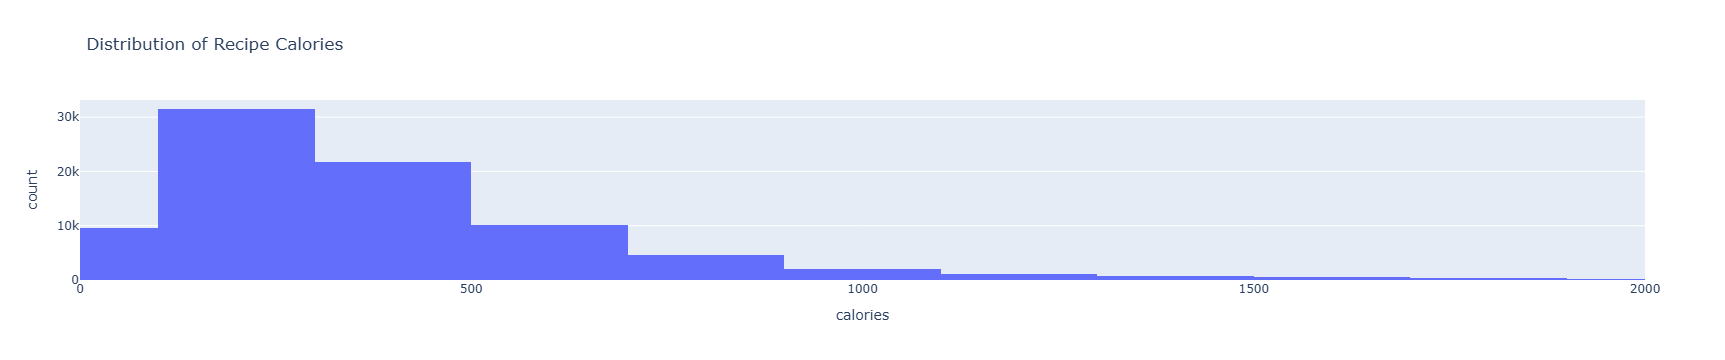

count    83782.000000
mean       429.926989
std        636.628493
min          0.000000
25%        171.325000
50%        305.400000
75%        498.700000
max      45609.000000
Name: calories, dtype: float64

In [24]:
# Plot distribution of calories
print(recipes[recipes['calories'] < 1000].shape[0] / recipes.shape[0])
fig = px.histogram(recipes, x='calories', title='Distribution of Recipe Calories', nbins=250)
fig.update_xaxes(range=[0, 2000])
fig.show()
fig.write_html('uni-calories.html', include_plotlyjs='cdn')
# Describe summary statistics on the 'calories' column
recipes['calories'].describe()

We performed the same analysis on our target `avg_rating` column as well. The histogram below shows the distribution of average ratings across all recipes from our sample dataset, in increments of .75 bins. Most recipes were rated 5 stars, with a left skew indicating lower rated Food.com recipes are sparser in our dataset. The describe function was also called on the "avg_ratings" column. From this EDA, we found that predicting a "high rated" recipe might prove more effective than predicting numerical features. This indicated a shift from prioritizing linear regression to classification. In fact, due to the concentration of five star recipes making up the bulk of the dataset, our question shifted to predicting a "Five Star" recipe, i.e. classification. 

In [7]:
fig_2 = px.histogram(recipes, x = 'avg_rating', nbins = 20, title = 'Distribution of Recipe Average Rating')
fig_2.show()
fig.write_html('uni-rating.html', include_plotlyjs='cdn')
recipes['avg_rating'].describe()

count    81173.000000
mean         4.625363
std          0.640763
min          1.000000
25%          4.500000
50%          5.000000
75%          5.000000
max          5.000000
Name: avg_rating, dtype: float64

### Bivariate Analysis

For our Bivariate Analysis, we wanted to compare the ratings of lower and higher caloric recipes. The box plot compares the distribution of average ratings between low-calorie (below median) and high-calorie (above median) recipes. Both groups have similar median ratings of around 5. The distributions are largely overlapping, suggesting that calorie content alone may not be a strong predictor of rating.


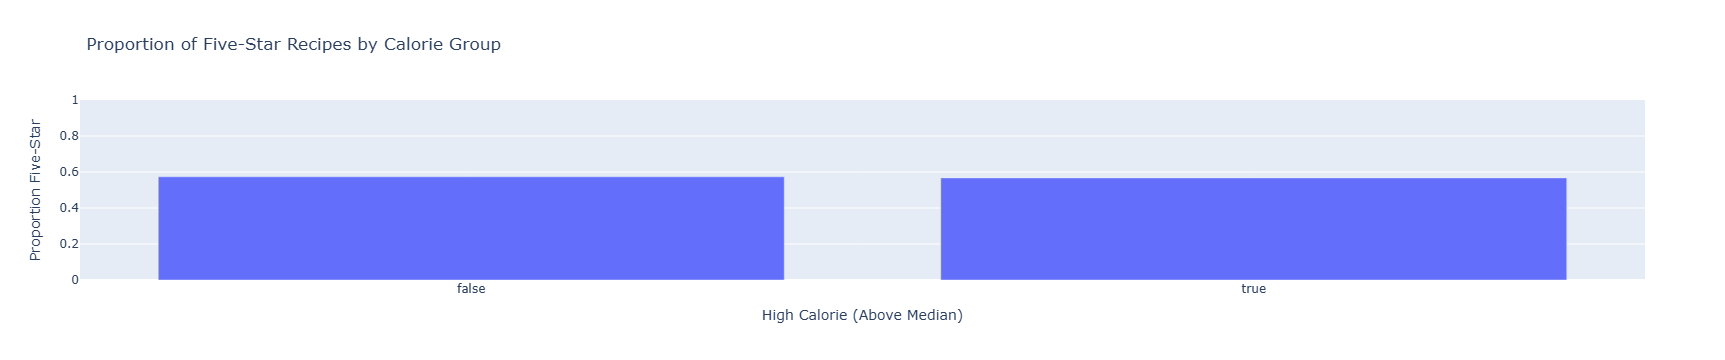

In [26]:
# Create high/low calorie groups and compare ratings
recipes['high_calorie'] = recipes['calories'] > recipes['calories'].median()

prop_df = (
    recipes
    .groupby('high_calorie')['five_star']
    .mean()
    .reset_index()
)

fig = px.bar(
    prop_df,
    x='high_calorie',
    y='five_star',
    title='Proportion of Five-Star Recipes by Calorie Group',
    labels={
        'high_calorie': 'High Calorie (Above Median)',
        'five_star': 'Proportion Five-Star'
    }
)
fig.update_yaxes(range=[0, 1])
fig.show()
fig.write_html('bivariate-rating-calorie.html', include_plotlyjs='cdn')

### Interesting Aggregates

The table shows the distribution of number of ingredients per recipe, as well as the resulting average calories, sugar, and average rating for each ingredient count. Recipes with only 1 ingredient tend to have much higher calories (714.65) and higher ratings (4.86) on average. As the number of ingredients increases, both calories and ratings slightly decrease. This suggests that recipes with less ingredients may be both more calorie-dense and reviewed more ratings. Sugar follows a roughly decreasing trend, while protein seems to increase as ingredients increase.

In [29]:
# Group by n_ingredients and compute mean calories and avg_rating
metrics = ['mean', 'median']
agg = recipes.groupby('n_ingredients')[['calories', 'total_fat', 'avg_rating']].agg({
    'calories': metrics,
    'total_fat': metrics,
    'avg_rating': metrics
}).round(2)
agg.head(10)

calories         total_fat        avg_rating       
                  mean  median      mean median       mean median
n_ingredients                                                    
1               714.65  200.35      0.91   0.03       4.86    5.0
2               331.98  148.10      0.26   0.03       4.69    5.0
3               306.11  166.70      0.22   0.06       4.66    5.0
4               336.01  195.60      0.24   0.09       4.63    5.0
5               347.80  224.20      0.25   0.13       4.65    5.0
6               355.89  245.55      0.26   0.15       4.63    5.0
7               391.13  272.30      0.30   0.18       4.62    5.0
8               387.03  290.90      0.30   0.20       4.61    5.0
9               422.50  306.55      0.32   0.21       4.61    5.0
10              449.82  322.00      0.35   0.22       4.61    5.0

## Step 3: Assessment of Missingness

### NMAR Analysis
The `description` column has 70 missing values. We believe this is likely NMAR, as recipe contributors who put less effort into their submission may skip writing a description, and those same contributors may also submit lower quality recipes. The missingness is therefore related to the actual value of the description itself (its quality/existence), not just other observed columns. Possible other data that were not captured in the dataset that might answer the question are account age and recipe submission history. Our best hypothesis is that the behavior of missing descriptions reflects patterns from newer users of Food.com, who may not be familiar or have the same desire to create more polished recipes.

### Missingness Dependency

We analyzed the missingness of `avg_rating`, which has 2,609 missing values. A recipe has a missing `avg_rating` if no users have rated it.

We tested whether the missingness of `avg_rating` depends on `calories`, `n_ingredients`, and `minutes` using permutation tests with the difference in means as our test statistic.

| Column | Observed Difference | P-value |
|--------|-------------------|---------|
| minutes | 117.342 | 0.0000 |
| n_steps | 1.493 | 0.0000 |
| calories | 87.859 | 0.0000 |

All three p-values are essentially 0, meaning we reject the null hypothesis that the missingness of `avg_rating` is independent of these columns. Recipes with missing ratings tend to have higher calories, more ingredients, and longer prep times. This suggests the missingness of `avg_rating` is **MAR** — dependent on other observed columns.

In [10]:
recipes.isnull().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description         70
ingredients          0
n_ingredients        0
avg_rating        2609
calories             0
total_fat            0
sugar                0
sodium               0
protein              0
saturated_fat        0
carbohydrates        0
submitted_year       0
five_star            0
high_calorie         0
dtype: int64

In [11]:
# Add a column indicating if avg_rating is missing
recipes['rating_missing'] = recipes['avg_rating'].isna()

# Compare distributions of calories and n_ingredients by missingness
print(recipes.groupby('rating_missing')[['calories', 'n_ingredients', 'minutes']].mean())

                  calories  n_ingredients     minutes
rating_missing                                       
False           427.191020       9.206103  111.376862
True            515.050326       9.460330  228.719049



minutes
Observed Difference: 117.342
P-value: 0.0000

n_steps
Observed Difference: 1.493
P-value: 0.0000

calories
Observed Difference: 87.859
P-value: 0.0000


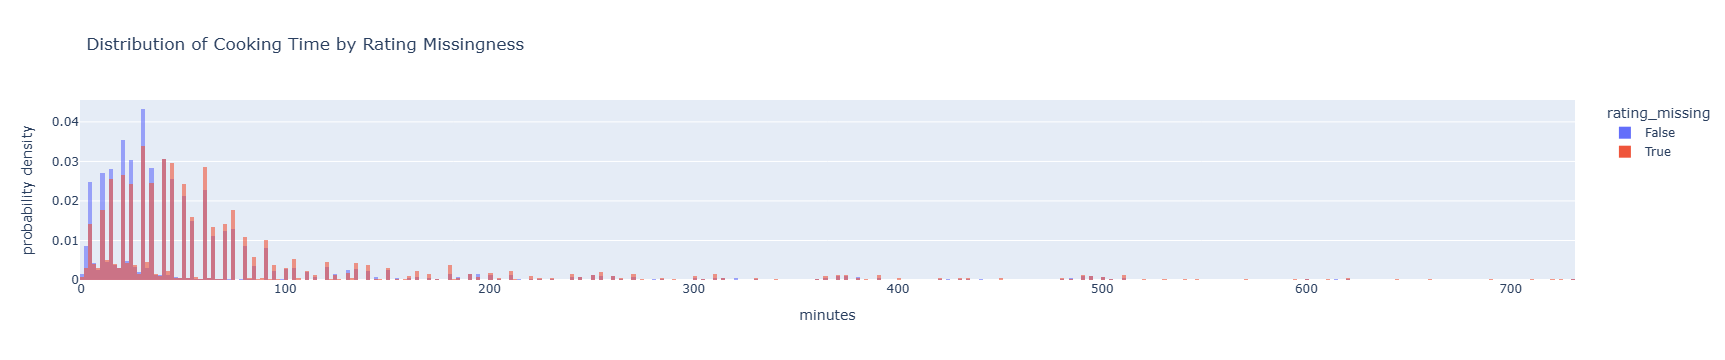

In [21]:
# Define permutatuion test function
def permutation_test(col, n=1000):
    observed = np.abs(
        recipes.groupby('rating_missing')[col]
               .mean()
               .diff()
               .iloc[-1]
    )

    diffs = []

    for _ in range(n):
        shuffled = recipes['rating_missing'].sample(
            frac=1,
            replace=False
        ).reset_index(drop=True)

        diff = (
            recipes[col][shuffled]
            .groupby(shuffled)
            .mean()
            .diff()
            .iloc[-1]
        )

        diffs.append(np.abs(diff))

    p_value = (np.array(diffs) >= observed).mean()

    return observed, p_value, diffs

# Run permutation tests and store results

results = {}

for col in ['minutes', 'n_steps', 'calories']:

    obs, p_value, diffs = permutation_test(col)

    results[col] = {
        'observed': obs,
        'p_value': p_value,
        'diffs': diffs
    }

    print(f'\n{col}')
    print(f'Observed Difference: {obs:.3f}')
    print(f'P-value: {p_value:.4f}')

import plotly.express as px

minutes_cutoff = recipes['minutes'].quantile(0.99)

plot_data = recipes[recipes['minutes'] <= minutes_cutoff]

fig = px.histogram(
    plot_data,
    x='minutes',
    color='rating_missing',
    histnorm='probability density',
    barmode='overlay',
    opacity=0.6,
    title='Distribution of Cooking Time by Rating Missingness'
)

fig.show()
fig.write_html('nmar-cooking.html', include_plotlyjs='cdn')

## Step 4: Hypothesis Testing

**Null Hypothesis:** High-protein recipes (above median protein content) and low-protein recipes (below median protein content) have the same average rating, and any observed difference is due to random chance.

**Alternative Hypothesis:** High-protein recipes are, on average, rated 5 stars, compared to lower protein recipes

**Test Statistic:** Difference in proportion of 5 star ratings

**Significance Level:** p <= 0.05

**Results:**
- Observed difference: -0.036
- P-value: 1

**Conclusion:** We fail to reject the null hypothesis. The p-value of 1 is far above our significance level of 0.05. In fact, the observed difference is slightly negative, meaning high-protein recipes are not rated 5 stars, on average. There is no statistically significant evidence that higher-protein recipes receive 5 star ratings compared to lower-protein recipes.

In [13]:
# Split into high and low protein groups
median_protein = recipes['protein'].median()

high_protein = recipes[recipes['protein'] > median_protein]['five_star']
low_protein = recipes[recipes['protein'] <= median_protein]['five_star']

# Observed difference in proportion of 5-star recipes
observed_diff = high_protein.mean() - low_protein.mean()

# Permutation test
diffs = []

combined = recipes['five_star'].dropna()

for _ in range(1000):

    shuffled = combined.sample(
        frac=1,
        replace=False
    ).reset_index(drop=True)

    perm_diff = (
        shuffled[:len(high_protein)].mean()
        - shuffled[len(high_protein):].mean()
    )

    diffs.append(perm_diff)

# One-sided test
p_value = (np.array(diffs) >= observed_diff).mean()

print('Observed diff:', observed_diff)
print('P-value:', p_value)

# Plot permutation distribution
fig = px.histogram(
    x=diffs,
    nbins=40,
    title='Permutation Distribution for Protein Rating Hypothesis Test',
    labels={
        'x': 'Difference in Proportion of 5-Star Recipes'
    }
)

fig.add_vline(
    x=observed_diff,
    line_dash='dash',
    annotation_text=f'Observed = {observed_diff:.3f}',
    annotation_position='top')
fig.update_layout(xaxis_title='Difference in Proportion (High Protein − Low Protein)',yaxis_title='Count')

fig.show()

fig.write_html('assets/protein_hypothesis_test.html',include_plotlyjs='cdn')

Observed diff: -0.036016450047030135
P-value: 1.0


## Step 5: Framing a Prediction Problem

**Prediction Problem:** Predict the rating performance of a recipe based on its characteristics and nutritional information.

**Type:** Classification - 'high_rated' recipes are defined as recipes with `avg_rating` of 5. 

**Response Variable:** `five_star` - we chose this because understanding what makes a recipe five stars is directly useful for recommending and developing recipes people will enjoy.

**Evaluation Metric:** F1-Score, (and as a consequence, Precision and Recall), due to a slight skew between 5 star recipes and non 5 star recipes. 

**Features available at time of prediction:**
- `calories`, `n_steps`, `n_ingredients`, `minutes` — all known before any ratings are submitted
- Nutrition values (`total fat, sugar, sodium, protein, etc.`)

To note is that we cannot use "Review" from the interactions dataframe, as these are post recipe features and are not available when a recipe is first submitted.

## Step 6: Baseline Model

**Model:** Logistic Regression with StandardScaler in a sklearn Pipeline

**Features (all quantitative):**
- `calories` — total calories, in #, per serving
- `n_steps` — number of steps in the recipe
- `n_ingredients` — number of ingredients
- `minutes` — total preparation time
- `total_fat`,`sugar`, `sodium`, `protein`, `saturated fat`, `carbohydrates` - total decimal proportion of daily value of the following nutrients present in recipe.


**All 10 features are quantitative** — no ordinal or nominal encodings were needed for this baseline.

**Performance:**
- Train F1: 0.53
- Test F1: 0.53
- Precision: 0.62
- Recall: 0.46

**Assessment:** The baseline model performs poorly. With an F1 of 0.53, the model only correctly predicts a 5 star recipe only half the time. Analyzing the quantitative features we had used on this model, we had only contributed measured features of the food recipe. We have still yet to touch on more abstract features like `tags`, preferential descriptive features like `ingredients`, time based measurements like `submitted_year`, all descriptions that can better capture patterns like general food.com user preferences, labels, membership between categories like "sweets", and larger societal trends towards food. All of these are avenues we plan to explore in the final model.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

# Drop rows with missing avg_rating
model_data = recipes.dropna(subset=['avg_rating']).copy()

# Features and target
features = ['calories', 'n_steps', 'n_ingredients', 'minutes', 'total_fat','sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']
X = model_data[features]
y = model_data['five_star']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline pipeline
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter = 1000, class_weight = 'balanced'))
])

baseline.fit(X_train, y_train)

y_train_pred = baseline.predict(X_train)
y_test_pred = baseline.predict(X_test)

# Metrics
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print("Train F1:", train_f1)
print("Test F1:", test_f1)
print("Precision:", precision)
print("Recall:", recall)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Train F1: 0.5298462826724086
Test F1: 0.527683007122763
Precision: 0.6165034965034965
Recall: 0.46123260437375746

Classification Report:
              precision    recall  f1-score   support

       False       0.43      0.59      0.50      6678
        True       0.62      0.46      0.53      9557

    accuracy                           0.51     16235
   macro avg       0.52      0.53      0.51     16235
weighted avg       0.54      0.51      0.52     16235



## Step 7: Final Model

For the final model, we include all the numeric features, as well as features we engineered.

### `submitted_year`

During testing, we found that including datetime introduced too many different concentrations of data points, making prediction harder. We decided to simplify the feature further, engineering `submitted_year` to include a temporal aspect of the dataset. Since tastes and preferences change throughout the years, we were interested in if we could perform efficient classification for data found in previous years, that may or may not have an average rating assigned to it for some reason or another. This, we found, could simulate past trends in Food.com recipes. Secondly, we were interested in later analyzing fairness between older and newer recipes.

### `ingredient_text`
The original `ingredients` column contains the recipe's ingredients, contained in a list. In recent years, we observed outside of the dataset that due to the increase in short form content, 'trendy' recipes like Tiramisu, Dubai Chocolate Cookies, and others would have signature ingredients that are the main focus of the recipe. Inspired by this, we wanted to engineer the feature further, hypothesizing that some popular ingredients may improve model accuracy, both in past and present prediction. To accomplish this, we found that preprocessing the ingredients by replacing spaces with underscores, then combining the entire ingredient list into a string provides the equivalent of a document. This allowed us to perform TF-IDF on the dataset, defining each unique preprocessed recipe as a tag.

### `tag_text`
The `tag` column contains the recipe's user submitted tags, contained in a list. Tags functionally serve to distinguish a recipe by giving it short descriptors, aiding users and administrators in finding similar recipes and identifying a recipe's more abstract descriptors and features. Because of this, transforming the list into a string document and performing TF-IDF, we believed, would provide further refinement into giving the model insight into a recipe's abstracted features for classification purposes.

The final model used:

* Logistic Regression
* TF-IDF feature extraction
* SelectKBest feature selection
* GridSearchCV hyperparameter tuning

Best parameters:

```python
kbest__k = 300
model__C = 10
```

### Performance

| Metric    | Baseline | Final |
| --------- | -------- | ----- |
| F1        | 0.53     | 0.60  |
| Precision | 0.62     | 0.66  |
| Recall    | 0.46     | 0.56  |

The addition of ingredient and tag information substantially improved performance, indicating that textual recipe information contains meaningful signals about recipe quality.

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif

# Engineer ingredients into a usable text document
model_data['ingredient_text'] = model_data['ingredients'].apply(
    lambda lst: ' '.join(ingredient.lower().replace(' ', '_') for ingredient in lst)
)

# Engineer tags into a usable text document
model_data['tag_text'] = model_data['tags'].apply(
    lambda x: ' '.join(x).lower()
)

# Define numeric features separately
numeric_features = [
    'calories',
    'n_steps',
    'n_ingredients',
    'minutes',
    'total_fat',
    'sugar',
    'sodium',
    'protein',
    'saturated_fat',
    'carbohydrates',
    'submitted_year'
]

# Define text features separately
text_features = [
    'ingredient_text', 
    'tag_text'
]

# Assign parameter grid to perform KBest tests on
param_grid = {
    'kbest__k': [50, 100, 200, 300],
    'model__C': [0.01, 0.1, 1, 10, 100]
}

# Setup preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    
    ('ingredients', TfidfVectorizer(max_features=300), 'ingredient_text'),

    ('tags', TfidfVectorizer(max_features=100), 'tag_text')
])

X = model_data[numeric_features + text_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create final model
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('kbest', SelectKBest(score_func=f_classif)),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    ))
])

# Define GridSearchCV
grid = GridSearchCV(
    final_model,
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit on training dataset]
grid.fit(X_train, y_train)

# Predict
y_pred = grid.predict(X_test)

best_model = grid.best_estimator_

# Print Data
print(grid.best_params_)
print("F1:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print(best_model.named_steps['model'].coef_)

{'kbest__k': 300, 'model__C': 10}
F1: 0.6036902875254698
Precision: 0.6575021575638023
Recall: 0.5580202992570891
[[-1.94183259e-01  6.93017158e-02  1.48602630e-01 -5.86939419e-03
   3.32000250e-02 -1.01901783e-03  9.66062264e-02  2.11230383e-01
   5.96631624e-03 -2.66412832e-01 -1.73570916e-01 -1.78138261e-01
  -1.69455600e-02  2.56158526e-01  3.65815750e-01 -1.35722842e-01
   1.03560990e-01  3.02251892e-01  3.53903031e-01 -6.73144883e-01
  -5.15488855e-02 -3.99362217e-02 -2.96266675e-01 -1.42336722e-01
   5.76839480e-01 -2.15891413e-01 -9.49774231e-02 -8.48280569e-02
   1.38272635e-01 -9.83804462e-02  1.63123460e-01  1.59992267e-01
  -2.29289244e-01 -2.25729171e-01 -2.04272707e-01  3.22038123e-01
   3.15444815e-02 -4.06457555e-01  1.20281858e-01 -2.95506428e-01
  -2.71513745e-01  4.21223225e-01  2.98366205e-02  4.26804205e-01
  -4.84789178e-02 -2.31917890e-01  3.13354007e-01 -5.83319633e-02
  -3.40943024e-01 -4.44131567e-01 -1.31793258e-01  1.01813461e-01
   2.24602703e-01 -3.3103380

## Step 8: Fairness Analysis

To assess whether our classifier treats different types of recipes equitably, we evaluated model performance across two calorie-based groups:

Low-calorie recipes: calories at or below the median calorie count (305.4 calories)
High-calorie recipes: calories above the median calorie count

This grouping was chosen because calorie content is one of the primary nutritional features used by the model and may influence prediction behavior.

Evaluation Metric

We compared the model's:

Precision
Recall
F1 Score

across both groups. Ideally, similar performance across groups would suggest that the model is not disproportionately favoring one calorie category over another.

Results

The model produced similar performance metrics across both calorie groups, with only modest differences in precision, recall, and F1 score. No group experienced a dramatic reduction in predictive performance.

Conclusion

The results suggest that the classifier does not exhibit substantial bias toward either high-calorie or low-calorie recipes. While minor performance differences are expected due to natural variation in the data, there is no evidence that one calorie group is systematically disadvantaged by the model.

However, this analysis is limited to calorie-based groups. Future work could examine fairness across other recipe characteristics, such as preparation time, number of ingredients, cuisine tags, or dietary categories. Additionally, because recipe ratings reflect subjective user preferences, differences in group performance may arise from underlying rating patterns rather than model bias alone.

Older recipe F1: 0.49571020019065776
Newer recipe F1: 0.7276042299744743
Observed Difference: 0.2318940297838165


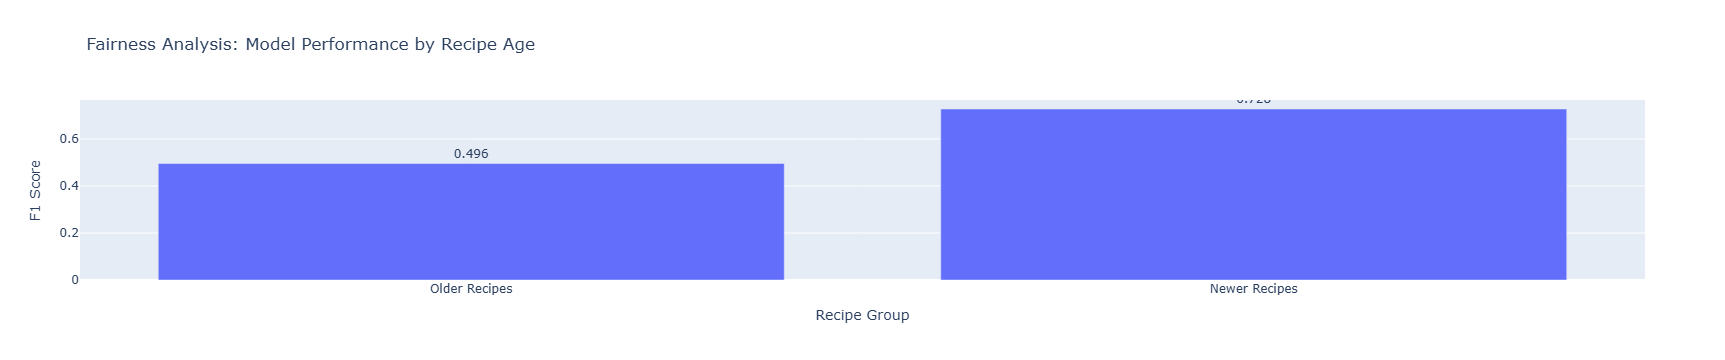

In [17]:
median_year = model_data['submitted_year'].median()

older_mask = X_test['submitted_year'] <= median_year
newer_mask = X_test['submitted_year'] > median_year

f1_old = f1_score(
    y_test[older_mask],
    y_pred[older_mask]
)

f1_new = f1_score(
    y_test[newer_mask],
    y_pred[newer_mask]
)

observed_diff = abs(f1_old - f1_new)

print("Older recipe F1:", f1_old)
print("Newer recipe F1:", f1_new)
print("Observed Difference:", observed_diff)

fairness_df = pd.DataFrame({
    'Group': ['Older Recipes', 'Newer Recipes'],
    'F1 Score': [f1_old, f1_new]
})

# Plot
fig = px.bar(
    fairness_df,
    x='Group',
    y='F1 Score',
    text='F1 Score',
    title='Fairness Analysis: Model Performance by Recipe Age'
)

fig.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside'
)

fig.update_layout(
    yaxis_title='F1 Score',
    xaxis_title='Recipe Group'
)

fig.show()

# Save for README embedding
fig.write_html(
    'assets/fairness_recipe_age.html',
    include_plotlyjs='cdn'
)